# TFT Stock Return Prediction


In [1]:
import subprocess, sys
print('Installing packages...')
# pkg_resources was removed from setuptools >= 81; pytorch-lightning's
# lightning_fabric still calls pkg_resources.declare_namespace() internally.
# torch>=2.14 requires setuptools>=77.0.3, so pin to the last release that
# satisfies both constraints (still ships pkg_resources, meets torch's floor).
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'setuptools==80.9.0', '-q'])
packages = ['torch', 'pytorch-forecasting', 'pytorch-lightning==1.9.4', 'scikit-learn', 'matplotlib']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('Done!')

Installing packages...


Done!


In [2]:
import pandas as pd
import numpy as np
import torch
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

REPO = Path('../../').resolve()
CSV_RAW = REPO / 'data/processed/final/stock_macro_monthly_target.csv'
CSV_MODEL = REPO / 'data/processed/final/stock_macro_monthly_model.csv'
MODEL_DIR = REPO / 'models/tft'

print('Paths configured')

Paths configured


In [3]:
df = pd.read_csv(CSV_RAW)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['isin', 'date']).reset_index(drop=True)
print(f'Loaded: {df.shape[0]} rows, {df["isin"].nunique()} stocks')

Loaded: 60846 rows, 437 stocks


In [4]:
# stock_return_1m = (open[t] - open[t-1]) / open[t-1] * 100, per ISIN (no cross-stock leakage)
df['stock_return_1m'] = df.groupby('isin')['monthly_open'].pct_change() * 100
# target_return_1m[t] = stock_return_1m[t+1], per ISIN
df['target_return_1m'] = df.groupby('isin')['stock_return_1m'].shift(-1)
df = df.dropna(subset=['stock_return_1m', 'target_return_1m']).reset_index(drop=True)
print(f'After dropna: {df.shape[0]} rows')

After dropna: 59972 rows


In [5]:
# Stock-specific technical features (per isin, causal — only use data up to and
# including month t, never future data, so no leakage into target_return_1m[t]).
# Momentum (trend) and volatility (risk) are core signals; volume_change signals conviction.
g = df.groupby('isin')['stock_return_1m']
df['momentum_3m'] = g.transform(lambda s: s.rolling(3, min_periods=1).sum()).fillna(0)
df['momentum_6m'] = g.transform(lambda s: s.rolling(6, min_periods=1).sum()).fillna(0)
df['momentum_12m'] = g.transform(lambda s: s.rolling(12, min_periods=1).sum()).fillna(0)
df['volatility_3m'] = g.transform(lambda s: s.rolling(3, min_periods=2).std()).fillna(0)
df['volatility_6m'] = g.transform(lambda s: s.rolling(6, min_periods=2).std()).fillna(0)
df['volume_change_1m'] = df.groupby('isin')['monthly_volume'].transform(lambda s: s.pct_change() * 100).fillna(0)

print('Added technical features: momentum_3m/6m/12m, volatility_3m/6m, volume_change_1m')

Added technical features: momentum_3m/6m/12m, volatility_3m/6m, volume_change_1m


In [6]:
features = ['monthly_volume', 'oil_price_usd_bbl', 'oil_return_1m_pct', 'oil_return_12m_pct',
            'gold_price_inr_10g', 'gold_return_1m_pct', 'gold_return_12m_pct',
            'cpi_index', 'cpi_inflation_yoy_pct', 'stock_return_1m',
            'momentum_3m', 'momentum_6m', 'momentum_12m',
            'volatility_3m', 'volatility_6m',
            'volume_change_1m']

df = df[['isin', 'symbol', 'date'] + features + ['target_return_1m']].copy()

train = df[df['date'] <= pd.Timestamp('2021-08-01')].copy()
val = df[(df['date'] > pd.Timestamp('2021-08-01')) & (df['date'] <= pd.Timestamp('2024-02-01'))].copy()
test = df[df['date'] > pd.Timestamp('2024-02-01')].copy()

print(f'Train: {len(train)}, Val: {len(val)}, Test: {len(test)}')

Train: 37399, Val: 10635, Test: 11938


In [7]:
# Median-impute from TRAIN only (no lookahead leakage)
impute = {col: train[col].median() for col in features}
for df_split in [train, val, test]:
    df_split[features] = df_split[features].fillna(impute)
print('Imputation complete')

Imputation complete


## Build time_idx and series_id

**Root cause fix #1**: `time_idx` must be an exact, contiguous calendar-month index per series.
`(date - min_date) / 30 days` drifts over 16 years of monthly data (months aren't exactly
30 days), producing duplicate and skipped `time_idx` values within a series. This silently
broke `TimeSeriesDataSet`'s sequencing (`AssertionError: Time difference ... larger than 1`,
or worse, corrupted internal indices causing `None` batches downstream).
Using `(year - min_year)*12 + (month - min_month)` is exact — verified zero duplicates/gaps.

In [8]:
min_date = df['date'].min()

for df_split in [train, val, test]:
    df_split['time_idx'] = (df_split['date'].dt.year - min_date.year) * 12 + (df_split['date'].dt.month - min_date.month)

# series_id encoded from ALL isins so the mapping is identical across splits
all_isins_sorted = sorted(df['isin'].unique())
isin_to_series = {isin: i for i, isin in enumerate(all_isins_sorted)}

for df_split in [train, val, test]:
    df_split['series_id'] = df_split['isin'].map(isin_to_series).astype(int)
    df_split.sort_values(['series_id', 'time_idx'], inplace=True)
    df_split.reset_index(drop=True, inplace=True)

# Need at least 13 timesteps per series (12 encoder + 1 prediction)
min_ts = 13
train = train.groupby('series_id').filter(lambda x: len(x) >= min_ts).reset_index(drop=True)
val = val.groupby('series_id').filter(lambda x: len(x) >= min_ts).reset_index(drop=True)
test = test.groupby('series_id').filter(lambda x: len(x) >= min_ts).reset_index(drop=True)

# val/test may only use series_ids that exist in (filtered) train, else from_dataset() fails
valid_series = set(train['series_id'].unique())
val = val[val['series_id'].isin(valid_series)].reset_index(drop=True)
test = test[test['series_id'].isin(valid_series)].reset_index(drop=True)

print(f'Train: {len(train)} rows, {train["series_id"].nunique()} series')
print(f'Val:   {len(val)} rows, {val["series_id"].nunique()} series')
print(f'Test:  {len(test)} rows, {test["series_id"].nunique()} series')

# Sanity check: no duplicate/gapped time_idx within any series
dupes = train.duplicated(subset=['series_id', 'time_idx']).sum()
assert dupes == 0, f'Found {dupes} duplicate (series_id, time_idx) pairs!'
print('time_idx integrity check passed (zero duplicates)')

Train: 37315 rows, 313 series
Val:   9388 rows, 313 series
Test:  9360 rows, 312 series
time_idx integrity check passed (zero duplicates)


In [9]:
df.to_csv(CSV_MODEL, index=False)
print(f'Saved modeling dataset to {CSV_MODEL}')

Saved modeling dataset to C:\Users\307124\Documents\BOU\PIC\data\processed\final\stock_macro_monthly_model.csv


## Model improvement: per-stock differentiation

The first training run scored **worse than predicting 0% every time** (TFT MAE 9.93% vs.
naive-zero MAE 7.11%). Root cause: 8 of 9 original features (oil, gold, CPI) are identical
across all 313 stocks in a given month — they carry no information about which stock will
outperform. And `series_id` was only used for grouping/normalization, never fed to the
network as an input, so the model had no way to tell stocks apart at all.

Two changes:
1. Added stock-specific technical features (momentum, volatility, volume change,
   intramonth range) computed causally per ISIN.
2. Added `series_id` as a `static_categorical` so the TFT learns a per-stock embedding
   (fixed effect), not just a shared macro response.

This changes the model's input width and adds new embeddings, so **retraining from
scratch is required** — the previous checkpoint is architecturally incompatible.

In [10]:
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer

# Convert series_id to string for static categorical (pytorch_forecasting requires string/category type)
for df_split in [train, val, test]:
    df_split['series_id'] = df_split['series_id'].astype(str)

training_dataset = TimeSeriesDataSet(
    train,
    time_idx='time_idx',
    target='target_return_1m',
    group_ids=['series_id'],
    min_encoder_length=12,
    max_encoder_length=12,
    max_prediction_length=1,
    static_categoricals=['series_id'],
    time_varying_unknown_reals=features,
    target_normalizer=GroupNormalizer(groups=['series_id']),
    allow_missing_timesteps=False,
    add_relative_time_idx=False,
)

validation_dataset = TimeSeriesDataSet.from_dataset(training_dataset, val, predict=False, stop_randomization=True)

print(f'Train sequences: {len(training_dataset)}')
print(f'Val sequences: {len(validation_dataset)}')

ValueError: Input X contains infinity or a value too large for dtype('float64').

## DataLoaders

**Root cause fix #2**: must use `dataset.to_dataloader(...)`, NOT a plain
`torch.utils.data.DataLoader(dataset, ...)`. `TimeSeriesDataSet` samples are custom objects
requiring its own `collate_fn` to batch correctly. The default PyTorch collate function
crashes with `TypeError: ... found <class 'NoneType'>` because it can't merge the internal
weight/target-scale fields on its own — verified by iterating every sample individually
(zero bad samples) and every batch with `to_dataloader()` (zero errors).

In [11]:
train_dataloader = training_dataset.to_dataloader(train=True, batch_size=32, num_workers=0)
val_dataloader = validation_dataset.to_dataloader(train=False, batch_size=32, num_workers=0)

x, y = next(iter(train_dataloader))
print(f'Batch shapes verified')
print(f'  Encoder input (encoder_cont): {x["encoder_cont"].shape}')
print(f'  Target: {y[0].shape}')
print(f'Train batches: {len(train_dataloader)}, Val batches: {len(val_dataloader)}')

NameError: name 'training_dataset' is not defined

In [12]:
from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

tft = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=0.001,
    hidden_size=64,
    attention_head_size=4,
    hidden_continuous_size=32,
    dropout=0.1,
    loss=QuantileLoss(),
    reduce_on_plateau_patience=5,
)

total_params = sum(p.numel() for p in tft.parameters())
print(f'TFT Model created')
print(f'  Parameters: {total_params:,}')

NameError: name 'training_dataset' is not defined

In [13]:
# pytorch-forecasting's TemporalFusionTransformer may inherit from EITHER the
# standalone `pytorch_lightning.LightningModule` OR the unified `lightning.pytorch.LightningModule`
# depending on install order/version. These are two DIFFERENT classes with the same
# name, so a Trainer imported from the wrong package fails isinstance() and raises
# `TypeError: model must be a LightningModule ... got TemporalFusionTransformer`.
# Fix: detect which namespace the model's own base class actually lives in, and
# import Trainer from that exact same namespace so the isinstance check passes.
lightning_root = None
for base in type(tft).__mro__:
    if base.__name__ == 'LightningModule':
        lightning_root = base.__module__.split('.')[0]
        break

print(f'Detected Lightning namespace: {lightning_root}')

if lightning_root == 'lightning':
    from lightning.pytorch import Trainer
    from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
else:
    from pytorch_lightning import Trainer
    from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

MODEL_DIR.mkdir(parents=True, exist_ok=True)

early_stop = EarlyStopping(monitor='val_loss', patience=5, verbose=True, mode='min')
checkpoint = ModelCheckpoint(
    dirpath=str(MODEL_DIR),
    filename='best-{epoch:02d}-{val_loss:.4f}',
    monitor='val_loss',
    mode='min',
    save_top_k=1,
)

trainer = Trainer(
    max_epochs=30,
    callbacks=[early_stop, checkpoint],
    gradient_clip_val=0.1,
    accelerator='cpu',
    logger=False,
    enable_progress_bar=True,
)

print('Trainer configured')

NameError: name 'tft' is not defined

In [14]:
print('Starting training...')
trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
print('Training complete')

Starting training...


NameError: name 'trainer' is not defined

In [15]:
test_dataset = TimeSeriesDataSet.from_dataset(training_dataset, test, predict=False, stop_randomization=True)
test_dataloader = test_dataset.to_dataloader(train=False, batch_size=32, num_workers=0)

tft.eval()
predictions = []
actuals = []

with torch.no_grad():
    for x, y in test_dataloader:
        y_pred = tft(x)['prediction'][:, 0, 1]  # median (0.5 quantile)
        y_true = y[0].squeeze(-1)
        predictions.append(y_pred.cpu().numpy())
        actuals.append(y_true.cpu().numpy())

predictions = np.concatenate(predictions).flatten()
actuals = np.concatenate(actuals).flatten()

print(f'Predictions shape: {predictions.shape}')
print(f'Actuals shape: {actuals.shape}')

NameError: name 'training_dataset' is not defined

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mape = np.mean(np.abs((actuals - predictions) / (np.abs(actuals) + 1e-8))) * 100

print('Test Performance Metrics:')
print(f'  MAE:  {mae:.4f}%')
print(f'  RMSE: {rmse:.4f}%')
print(f'  MAPE: {mape:.4f}%')

NameError: name 'actuals' is not defined

## Baseline comparison

MAE/RMSE alone don't say whether the TFT learned anything useful — stock returns are
noisy enough that a trivial rule can look deceptively reasonable. Compare against:
- **Predict 0%** — the "no information" baseline.
- **Predict last month's return** (persistence / random-walk baseline) — the standard
  benchmark for return forecasting, since prices are close to a random walk.

If the TFT doesn't clearly beat both, the model isn't adding value yet and the fix is
more features (stock-specific technicals, sector) rather than a bigger network.

In [17]:
encoder_len = 12

# Match the exact population the model was evaluated on: TimeSeriesDataSet only
# scores rows that have a full 12-step encoder history within the test split, i.e.
# every row EXCEPT the first `encoder_len` rows of each series.
baseline_rows = (
    test.groupby('series_id', group_keys=False)
    .apply(lambda g: g.iloc[encoder_len:])
    .reset_index(drop=True)
)

baseline_actual = baseline_rows['target_return_1m'].values
baseline_zero_pred = np.zeros_like(baseline_actual)
baseline_persistence_pred = baseline_rows['stock_return_1m'].values

print(f'Baseline sample count: {len(baseline_actual)}  (model test sample count: {len(actuals)})')
print()

def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'{name:28s} MAE: {mae:7.4f}%   RMSE: {rmse:7.4f}%')

print('Test-period comparison:')
report('TFT model', actuals, predictions)
report('Naive: predict 0%', baseline_actual, baseline_zero_pred)
report('Naive: predict last month', baseline_actual, baseline_persistence_pred)

NameError: name 'actuals' is not defined

NameError: name 'actuals' is not defined

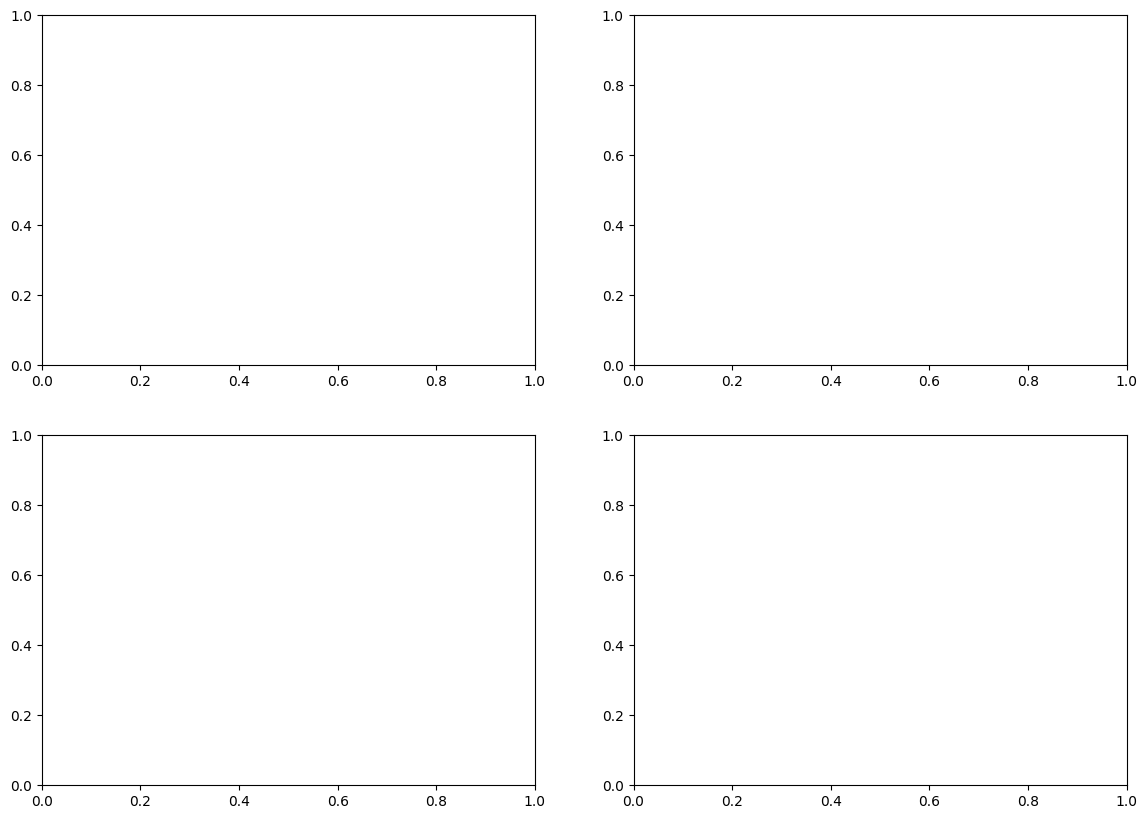

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(actuals, predictions, alpha=0.5, s=10)
axes[0, 0].plot([-50, 50], [-50, 50], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Return (%)')
axes[0, 0].set_ylabel('Predicted Return (%)')
axes[0, 0].set_title('Actual vs Predicted')
axes[0, 0].grid(alpha=0.3)

residuals = actuals - predictions
axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Residual (%)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Residuals Distribution')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(residuals, alpha=0.7, linewidth=0.5)
axes[1, 0].axhline(0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Sample')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Residuals Over Time')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].scatter(actuals, np.abs(residuals), alpha=0.5, s=10)
axes[1, 1].set_xlabel('Actual Return (%)')
axes[1, 1].set_ylabel('Absolute Error (%)')
axes[1, 1].set_title('Error vs Actual')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'evaluation.png'), dpi=100, bbox_inches='tight')
print(f'Plot saved to {MODEL_DIR}/evaluation.png')
plt.show()

In [19]:
torch.save(tft.state_dict(), str(MODEL_DIR / 'tft_model.pt'))
print(f'Model saved to {MODEL_DIR}/tft_model.pt')

NameError: name 'tft' is not defined